# Exploratory Data Analysis: Crime Data
This notebook explores the crime dataset.
We will look at frequencies of different crime types, geographic distribution by neighborhood, and time-series trends.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Configure visual settings
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)


In [ ]:
# Load the dataset
df = pd.read_csv('../../data/staging/crime_transformed_20260320.csv')

# Convert timestamp to datetime
df['timestamp'] = pd.to_datetime(df['timestamp'], errors='coerce')

# Display the first few rows to understand the structure
df.head()


,type,hundred_block,neighbourhood,timestamp,latitude,longitude
0,Break and Enter Commercial,10XX ALBERNI ST,West End,2023-09-14 03:30:00,49.284853,-123.122857
1,Break and Enter Commercial,10XX BARCLAY ST,West End,2024-02-24 04:08:00,49.282251,-123.125602
2,Break and Enter Commercial,10XX BEACH AVE,West End,2023-04-01 04:07:00,49.276827,-123.134763
3,Break and Enter Commercial,10XX BEACH AVE,West End,2025-04-28 12:05:00,49.276572,-123.134358
4,Break and Enter Commercial,10XX BEACH AVE,Central Business District,2023-05-11 18:00:00,49.276180,-123.134055


In [3]:
# Basic summary
print("Number of records:", len(df))
print("\nTime range:")
print("Start:", df['timestamp'].min())
print("End:", df['timestamp'].max())

print("\nMissing values:")
display(df.isnull().sum())


Number of records: 875675

Time range:
Start: 2003-01-01 00:00:00
End: 2026-03-12 21:27:00

Missing values:


type                 0
hundred_block       12
neighbourhood       92
timestamp        16666
latitude         47561
longitude        47561
dtype: int64

C:\Users\Chris\AppData\Local\Temp\ipykernel_19564\1962911104.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='type', data=df, order=df['type'].value_counts().index, palette='viridis')


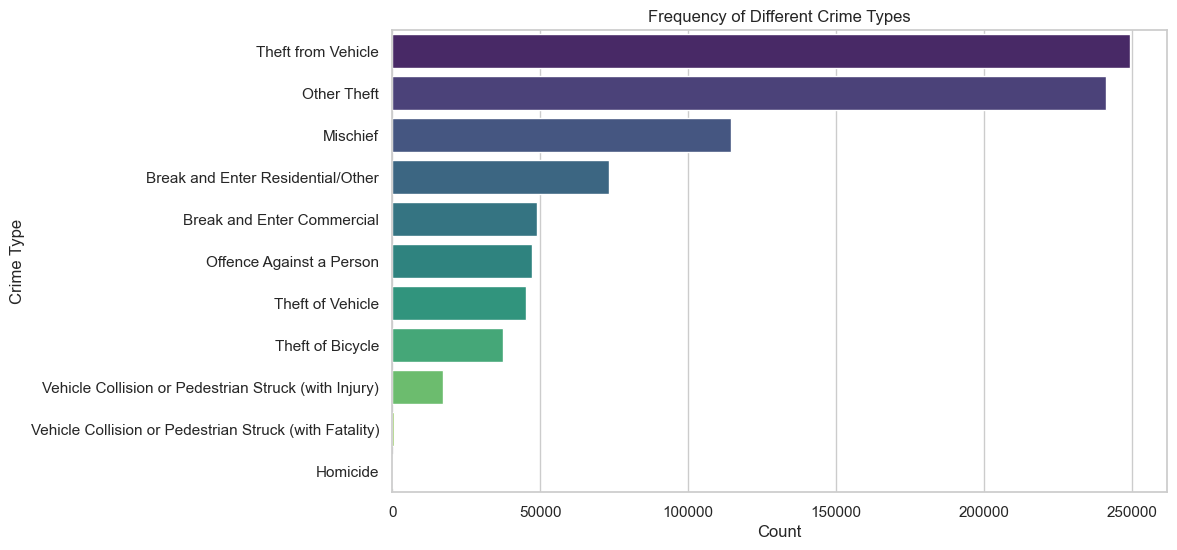

In [4]:
# Bar chart for Crime Types
plt.figure(figsize=(10, 6))
sns.countplot(y='type', data=df, order=df['type'].value_counts().index, palette='viridis')
plt.title('Frequency of Different Crime Types')
plt.xlabel('Count')
plt.ylabel('Crime Type')
plt.show()


C:\Users\Chris\AppData\Local\Temp\ipykernel_19564\4027521702.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='neighbourhood', data=df[df['neighbourhood'].isin(top_neighborhoods)], order=top_neighborhoods, palette='magma')


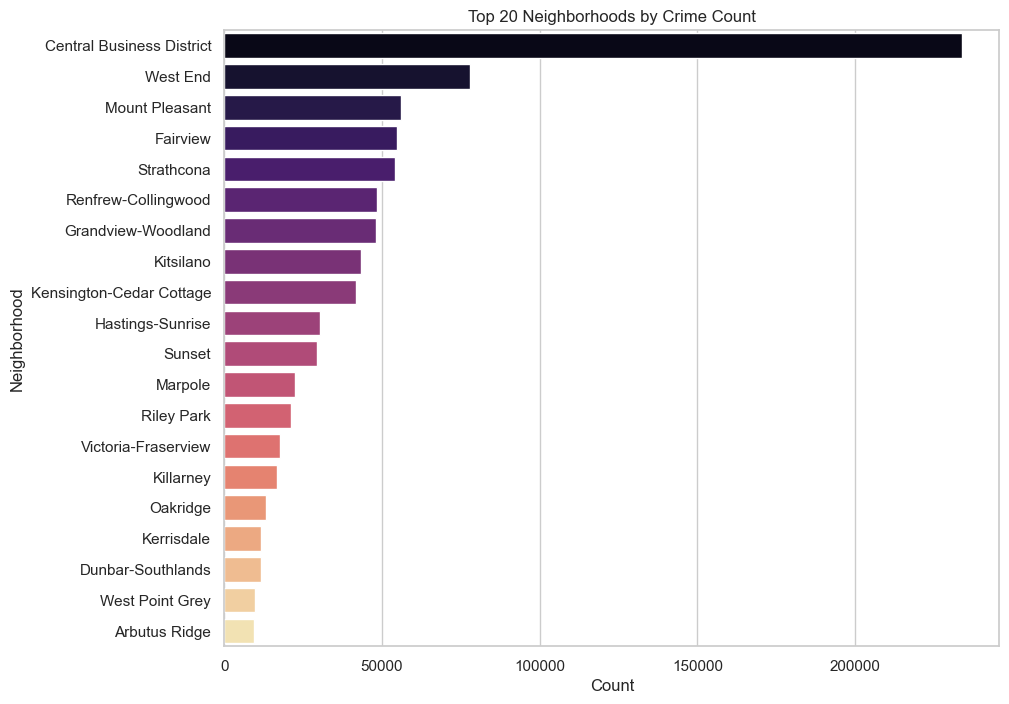

In [5]:
# Bar chart for Top Neighborhoods
plt.figure(figsize=(10, 8))
top_neighborhoods = df['neighbourhood'].value_counts().head(20).index
sns.countplot(y='neighbourhood', data=df[df['neighbourhood'].isin(top_neighborhoods)], order=top_neighborhoods, palette='magma')
plt.title('Top 20 Neighborhoods by Crime Count')
plt.xlabel('Count')
plt.ylabel('Neighborhood')
plt.show()


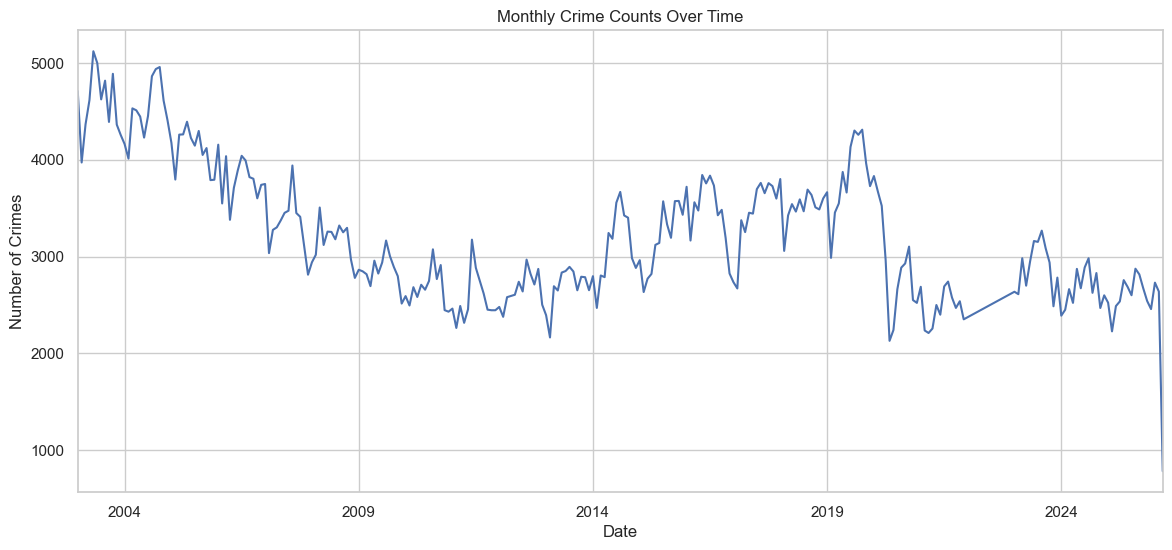

In [6]:
# Time-series analysis of Crimes
# Extract year and month for trend analysis
df['year_month'] = df['timestamp'].dt.to_period('M')

# Count crimes per month
monthly_counts = df.groupby('year_month').size()

plt.figure(figsize=(14, 6))
monthly_counts.plot()
plt.title('Monthly Crime Counts Over Time')
plt.xlabel('Date')
plt.ylabel('Number of Crimes')
plt.show()


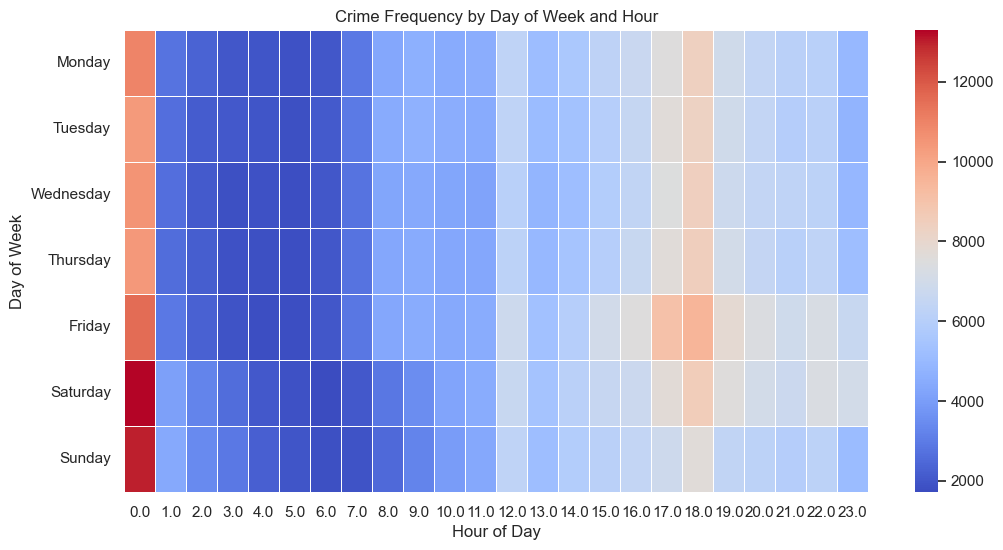

In [ ]:
# We will do a heatmap of Crime counts by Day of Week and Hour instead
df['hour'] = df['timestamp'].dt.hour
df['day_of_week'] = df['timestamp'].dt.day_name()

# Order days
days = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

heatmap_data = df.groupby(['day_of_week', 'hour']).size().unstack()
heatmap_data = heatmap_data.reindex(days)

plt.figure(figsize=(12, 6))
sns.heatmap(heatmap_data, cmap='coolwarm', linewidths=.5)
plt.title('Crime Frequency by Day of Week and Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Day of Week')
plt.show()
